Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

reading data

In [ ]:
df=pd.read_csv("data.csv")

understanding data

In [ ]:
print(df.shape)            #rows:columns
print(df.head())           #frst 5 rows
print(df.dtypes)           #datatypes of each column
print(df.isnull().sum())  #checking for null values
print(df.describe())       #statistics of the data like mean,max,min etc

(100, 2)
   square_footage  monthly_rent
0            2053          4291
1            1235          2289
2            1163          2694
3            2131          4567
4            1433          2576
square_footage    int64
monthly_rent      int64
dtype: object
square_footage    0
monthly_rent      0
dtype: int64
       square_footage  monthly_rent
count       100.00000    100.000000
mean       1523.81000   3070.060000
std         629.67068   1271.434415
min         484.00000    697.000000
25%        1038.50000   2026.750000
50%        1528.00000   2935.500000
75%        2099.50000   4336.250000
max        2480.00000   5183.000000


selecting variables for input and output

In [ ]:
X = df[['square_footage']]   # Independent variable (input)
y = df['monthly_rent']       # Dependent variable (output/target)

visuallizing data for better understanding

Text(0.5, 1.0, 'Square Footage vs Monthly Rent')

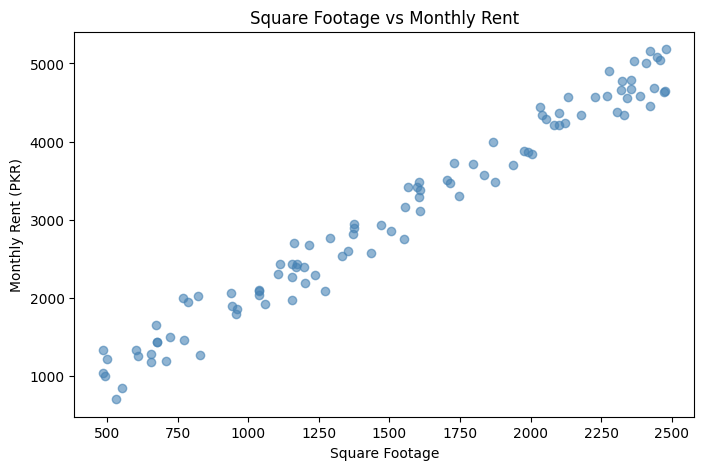

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='steelblue', alpha=0.6)
plt.xlabel('Square Footage')
plt.ylabel('Monthly Rent (PKR)')
plt.title('Square Footage vs Monthly Rent')

Splitting data for testing and training

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")


Training samples : 80
Testing  samples : 20


Training the model using Linear Regression

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)   #here model learns data like for what value x
                               # what is the value of y

slope     = model.coef_[0]      # m — how much rent rises per extra sq ft
intercept = model.intercept_    # b — base rent at 0 sq ft

print(f"\n--- Model Coefficients ---")
print(f"Slope (m)     : {slope:.4f}  → each extra sq ft adds ${slope:.2f}/month")
print(f"Intercept (b) : {intercept:.2f}")
print(f"Formula       : rent = {slope:.2f} × sqft + {intercept:.2f}")


--- Model Coefficients ---
Slope (m)     : 2.0003  → each extra sq ft adds $2.00/month
Intercept (b) : 25.72
Formula       : rent = 2.00 × sqft + 25.72


Testing the model

In [ ]:
y_pred = model.predict(X_test)   #we ask the model to predict rent for some
                                  #X_value

mae = mean_absolute_error(y_test, y_pred) #compares the result with actuall value

r2  = r2_score(y_test, y_pred)  #variation in rent

print(f"\n--- Evaluation Metrics ---")
print(f"MAE (Mean Absolute Error) : PKR {mae:.2f}")
print(f"  → On average, predictions are off by: PKR {mae:.2f}")
print(f"R² Score                  : {r2:.4f}")
print(f"  → The model explains {r2*100:.1f}% of the variation in rent")


--- Evaluation Metrics ---
MAE (Mean Absolute Error) : PKR 206.42
  → On average, predictions are off by: PKR 206.42
R² Score                  : 0.9591
  → The model explains 95.9% of the variation in rent


plotting the regression line

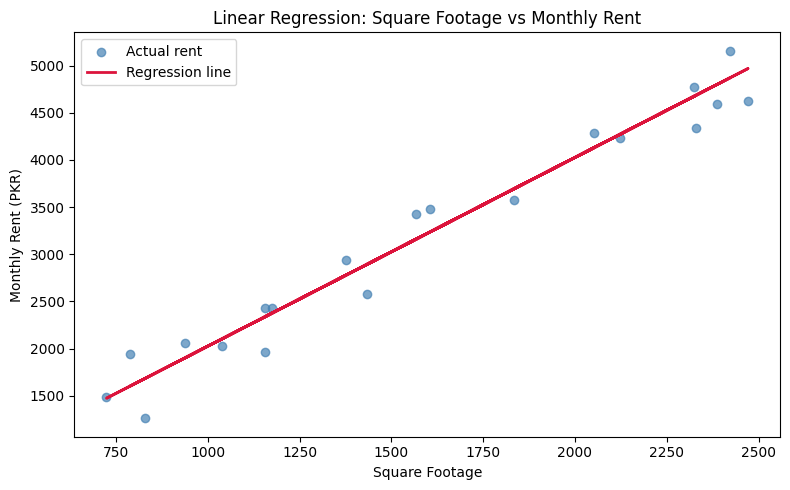

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, color='steelblue', alpha=0.7,
            label='Actual rent')
plt.plot(X_test, y_pred, color='crimson', linewidth=2,
         label='Regression line')
plt.xlabel('Square Footage')
plt.ylabel('Monthly Rent (PKR)')
plt.title('Linear Regression: Square Footage vs Monthly Rent')
plt.legend()
plt.tight_layout()



Visualize Model Performance

If the model were perfect, every dot would sit on the red line.

Points far from the line = bigger prediction errors.


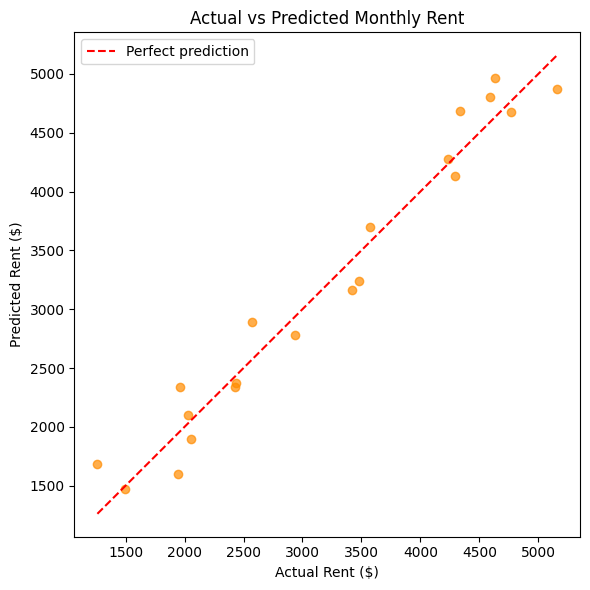

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, color='darkorange', alpha=0.7)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5,
         label='Perfect prediction')
plt.xlabel('Actual Rent ($)')
plt.ylabel('Predicted Rent ($)')
plt.title('Actual vs Predicted Monthly Rent')
plt.legend()
plt.tight_layout()


Making new prediction

In [ ]:
new_apartments = pd.DataFrame({'square_footage': [500, 1000, 1500, 2000, 2500]})
predicted_rents = model.predict(new_apartments)

print("\n--- Predictions on New Apartments ---")
for sqft, rent in zip(new_apartments['square_footage'], predicted_rents):
    print(f"  {sqft} sq ft  →  PKR {rent:,.0f}/month")


--- Predictions on New Apartments ---
  500 sq ft  →  PKR 1,026/month
  1000 sq ft  →  PKR 2,026/month
  1500 sq ft  →  PKR 3,026/month
  2000 sq ft  →  PKR 4,026/month
  2500 sq ft  →  PKR 5,027/month


Interpreting the Results

In [ ]:
print("""
==============================================
INTERPRETATION
==============================================

Regression Coefficient (Slope = {slope:.2f}):
  For every 1 extra square foot, monthly rent
  increases by approximately ${slope:.2f}.
  Example: 100 sq ft bigger = ~${big:.0f} more/month.

R² = {r2:.4f} ({pct:.1f}%):
  The model explains {pct:.1f}% of the variation
  in monthly rent using only square footage.
  This is a strong fit for a single variable.

MAE = ${mae:.2f}:
  On average, predictions are off by ${mae:.2f}.
  Given rents range $697–$5183, this error is
  relatively small and acceptable.

Conclusion:
  Square footage is a strong predictor of rent.
  Linear regression works well for this dataset.
==============================================
""".format(slope=slope, big=slope*100, r2=r2, pct=r2*100, mae=mae))


INTERPRETATION
 
Regression Coefficient (Slope = 2.00):
  For every 1 extra square foot, monthly rent
  increases by approximately $2.00.
  Example: 100 sq ft bigger = ~$200 more/month.
 
R² = 0.9591 (95.9%):
  The model explains 95.9% of the variation
  in monthly rent using only square footage.
  This is a strong fit for a single variable.
 
MAE = $206.42:
  On average, predictions are off by $206.42.
  Given rents range $697–$5183, this error is
  relatively small and acceptable.
 
Conclusion:
  Square footage is a strong predictor of rent.
  Linear regression works well for this dataset.

